In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

In [2]:
# Load dataset
file_path = "../data/raw/project_master_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
df.head()

Dataset loaded successfully.
Shape of dataset: (100, 13)


,project_id,project_title,project_type,deadline_days,base_revenue,complexity_level,client_priority,team_experience_level,historical_delay_rate,actual_completion_days,completed_on_time,delay_days,final_revenue_realized
0,1,E-Commerce Platform,Web Development,3,80000,Medium,High,Senior Team,15%,2,Yes,0,80000
1,2,Payment API Integration,Backend Development,2,60000,High,Very High,Mid-Level Team,30%,3,No,1,54000
2,3,Mobile UI Enhancement,Mobile Development,1,50000,Low,Medium,Senior Team,10%,1,Yes,0,50000
3,4,CRM System Upgrade,Web Development,4,100000,Very High,Very High,Junior Team,40%,5,No,1,90000
4,5,SEO Optimization,Marketing,2,30000,Very Low,Low,Senior Team,5%,2,Yes,0,30000


In [3]:
# Basic information
print("Data Info:")
df.info()

print("\nSummary Statistics (Numerical Columns):")
df.describe()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   project_id              100 non-null    int64 
 1   project_title           100 non-null    object
 2   project_type            100 non-null    object
 3   deadline_days           100 non-null    int64 
 4   base_revenue            100 non-null    int64 
 5   complexity_level        100 non-null    object
 6   client_priority         100 non-null    object
 7   team_experience_level   100 non-null    object
 8   historical_delay_rate   100 non-null    object
 9   actual_completion_days  100 non-null    int64 
 10  completed_on_time       100 non-null    object
 11  delay_days              100 non-null    int64 
 12  final_revenue_realized  100 non-null    int64 
dtypes: int64(6), object(7)
memory usage: 10.3+ KB

Summary Statistics (Numerical Columns):


,project_id,deadline_days,base_revenue,actual_completion_days,delay_days,final_revenue_realized
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,50.500000,2.840000,87280.000000,3.170000,0.340000,82939.00000
std,29.011492,1.143449,44700.819146,1.470621,0.476095,40182.17328
min,1.000000,1.000000,20000.000000,1.000000,0.000000,20000.00000
25%,25.750000,2.000000,58000.000000,2.000000,0.000000,54675.00000
50%,50.500000,3.000000,82500.000000,3.000000,0.000000,81950.00000
75%,75.250000,4.000000,115750.000000,4.000000,1.000000,105300.00000
max,100.000000,5.000000,195000.000000,6.000000,1.000000,175500.00000


In [4]:
# Missing value analysis
missing_values = df.isnull().sum()

print("Missing Values Per Column:")
print(missing_values)

Missing Values Per Column:
project_id                0
project_title             0
project_type              0
deadline_days             0
base_revenue              0
complexity_level          0
client_priority           0
team_experience_level     0
historical_delay_rate     0
actual_completion_days    0
completed_on_time         0
delay_days                0
final_revenue_realized    0
dtype: int64


In [6]:
# Create numeric version of historical_delay_rate for analysis
df['historical_delay_rate_numeric'] = df['historical_delay_rate'].str.replace('%', '').astype(float) / 100

df.head()

,project_id,project_title,project_type,deadline_days,base_revenue,complexity_level,client_priority,team_experience_level,historical_delay_rate,actual_completion_days,completed_on_time,delay_days,final_revenue_realized,historical_delay_rate_numeric
0,1,E-Commerce Platform,Web Development,3,80000,Medium,High,Senior Team,15%,2,Yes,0,80000,0.15
1,2,Payment API Integration,Backend Development,2,60000,High,Very High,Mid-Level Team,30%,3,No,1,54000,0.30
2,3,Mobile UI Enhancement,Mobile Development,1,50000,Low,Medium,Senior Team,10%,1,Yes,0,50000,0.10
3,4,CRM System Upgrade,Web Development,4,100000,Very High,Very High,Junior Team,40%,5,No,1,90000,0.40
4,5,SEO Optimization,Marketing,2,30000,Very Low,Low,Senior Team,5%,2,Yes,0,30000,0.05


Completion Distribution (%):
completed_on_time
Yes    66.0
No     34.0
Name: proportion, dtype: float64


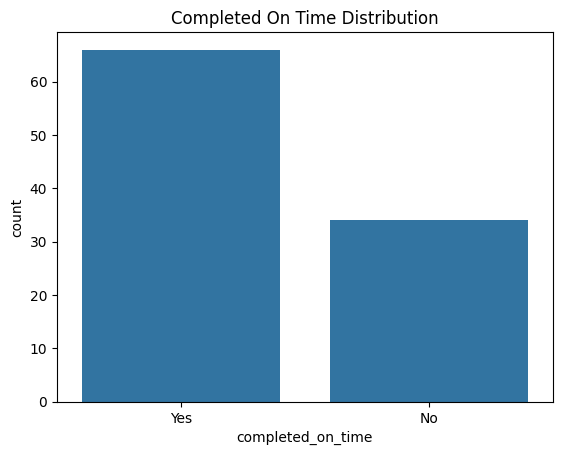

In [7]:
# Delay distribution
delay_percentage = df['completed_on_time'].value_counts(normalize=True) * 100

print("Completion Distribution (%):")
print(delay_percentage)

sns.countplot(x='completed_on_time', data=df)
plt.title("Completed On Time Distribution")
plt.show()

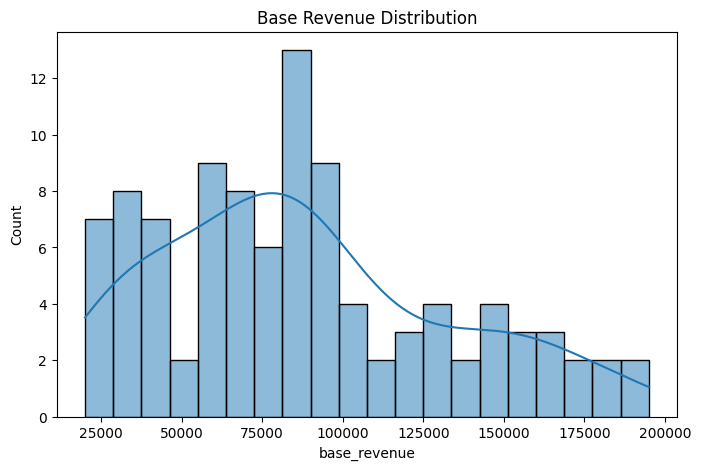

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['base_revenue'], bins=20, kde=True)
plt.title("Base Revenue Distribution")
plt.show()

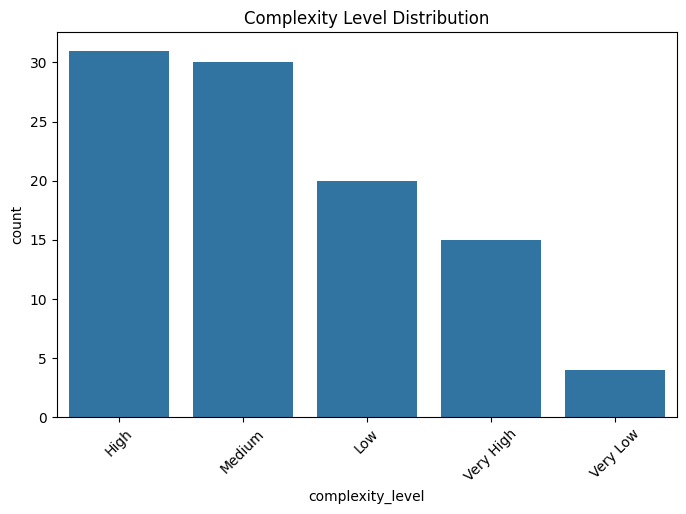

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='complexity_level', data=df, order=df['complexity_level'].value_counts().index)
plt.title("Complexity Level Distribution")
plt.xticks(rotation=45)
plt.show()

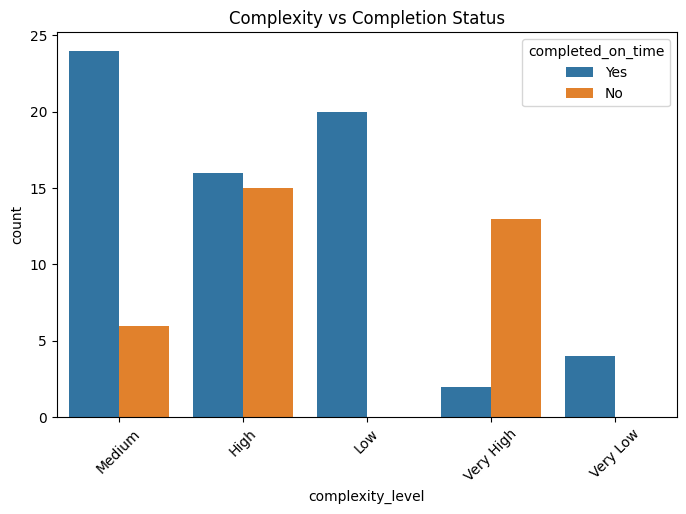

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x='complexity_level', hue='completed_on_time', data=df)
plt.title("Complexity vs Completion Status")
plt.xticks(rotation=45)
plt.show()

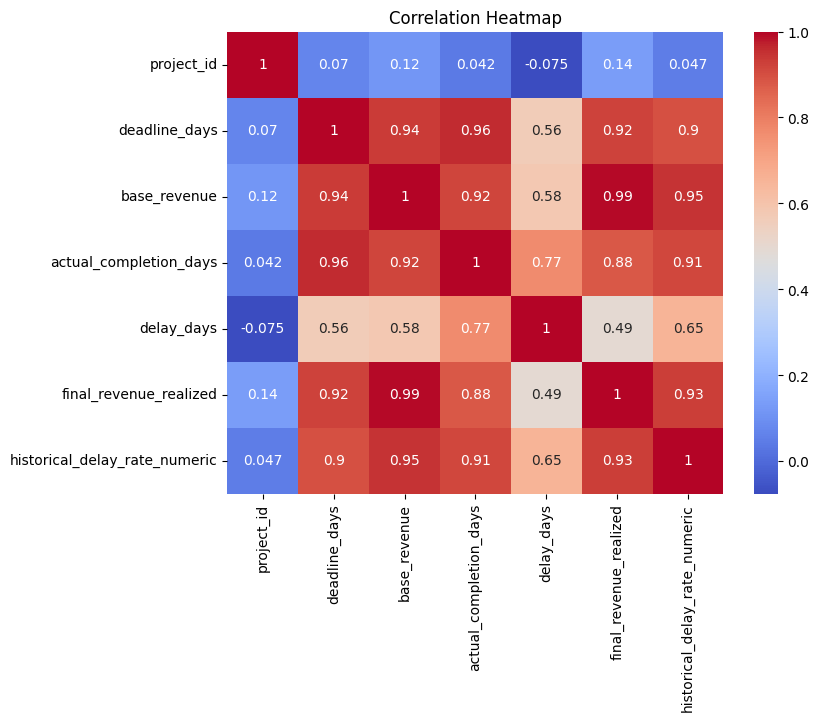

In [11]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()